In [17]:
#@title 1. Import required libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import io
import warnings
warnings.filterwarnings('ignore')

print("PyTorch version:", torch.__version__)
print("Libraries imported.")

PyTorch version: 2.10.0+cpu
Libraries imported.


Please select an image file (jpg, jpeg, png) from your computer.


Saving dog.jpg to dog (2).jpg
Uploaded file: dog (2).jpg


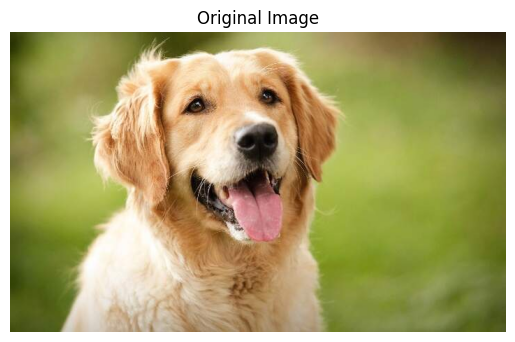

In [18]:
#@title 2. Upload an image from your computer
print("Please select an image file (jpg, jpeg, png) from your computer.")
uploaded = files.upload()

filename = next(iter(uploaded))
print(f"Uploaded file: {filename}")

# Open and display the image
img = Image.open(io.BytesIO(uploaded[filename])).convert('RGB')
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')
plt.show()

In [19]:
#@title 3. Preprocess the image for both networks
input_size = 64

transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),                       # scales pixel values to [0,1]
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # approximate ImageNet stats
                         std=[0.229, 0.224, 0.225])    # (not strictly necessary but keeps values reasonable)
])

input_tensor = transform(img).unsqueeze(0)  # add batch dimension: (1, 3, 64, 64)
print("Input tensor shape:", input_tensor.shape)

Input tensor shape: torch.Size([1, 3, 64, 64])


In [20]:
#@title 4. Define a simple FCNN and a feature extractor using forward hooks
class SimpleFCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Input is flattened image: 3*64*64 = 12288
        self.fc1 = nn.Linear(3 * input_size * input_size, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)  # not used for feature extraction

    def forward(self, x):
        x = x.view(x.size(0), -1)       # flatten
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)                  # no activation on final layer for this demo
        return x

fcnn_model = SimpleFCNN()
fcnn_model.eval()

fcnn_activations = {}

def get_fcnn_activation(name):
    def hook(model, input, output):
        fcnn_activations[name] = output.detach()
    return hook

# Register hooks on the two hidden linear layers
fcnn_model.fc1.register_forward_hook(get_fcnn_activation('fc1'))
fcnn_model.fc2.register_forward_hook(get_fcnn_activation('fc2'))

print("FCNN model defined:")
print(fcnn_model)

FCNN model defined:
SimpleFCNN(
  (fc1): Linear(in_features=12288, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [21]:
#@title 5. Define a simple CNN and a feature extractor using forward hooks
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Two convolutional layers with ReLU and max pooling
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)  # out: 16x64x64
        self.pool1 = nn.MaxPool2d(2, 2)                           # out: 16x32x32
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1) # out: 32x32x32
        self.pool2 = nn.MaxPool2d(2, 2)                           # out: 32x16x16
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # out: 64x16x16

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = F.relu(self.conv3(x))
        return x

# Instantiate the CNN
cnn_model = SimpleCNN()
cnn_model.eval()

# We'll use forward hooks to capture intermediate outputs
cnn_activations = {}

def get_activation(name):
    def hook(model, input, output):
        cnn_activations[name] = output.detach()
    return hook

# Register hooks on the layers we want to visualize
cnn_model.conv1.register_forward_hook(get_activation('conv1'))
cnn_model.conv2.register_forward_hook(get_activation('conv2'))
cnn_model.conv3.register_forward_hook(get_activation('conv3'))

print("CNN model defined:")
print(cnn_model)

CNN model defined:
SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)


In [22]:
#@title 6. Pass the image through both networks and capture activations
with torch.no_grad():
    _ = cnn_model(input_tensor)
    _ = fcnn_model(input_tensor)

print("CNN activations recorded for layers:", list(cnn_activations.keys()))
for name, act in cnn_activations.items():
    print(f"  {name}: {act.shape}")

print("\nFCNN activations recorded for layers:", list(fcnn_activations.keys()))
for name, act in fcnn_activations.items():
    print(f"  {name}: {act.shape}")

CNN activations recorded for layers: ['conv1', 'conv2', 'conv3']
  conv1: torch.Size([1, 16, 64, 64])
  conv2: torch.Size([1, 32, 32, 32])
  conv3: torch.Size([1, 64, 16, 16])

FCNN activations recorded for layers: ['fc1', 'fc2']
  fc1: torch.Size([1, 256])
  fc2: torch.Size([1, 128])


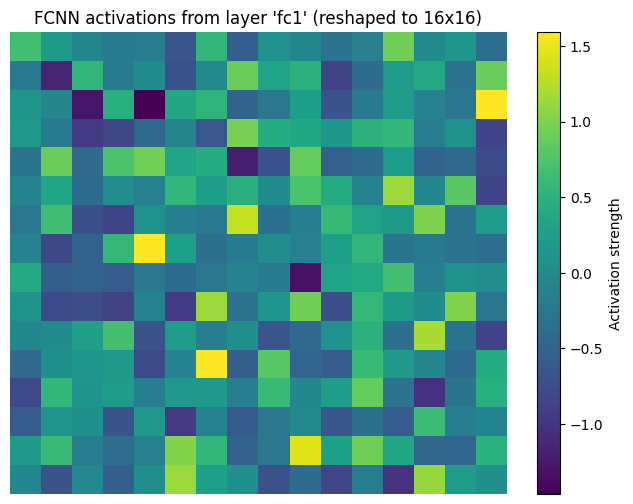

In [24]:
#@title 7. Visualize FCNN activations
# FCNN activations are 1D vectors. We'll reshape them into a 2D image-like representation
# if the number of neurons is a perfect square, otherwise into a rectangle.
# For fc1 we have 256 neurons -> 16x16 grid; for fc2 we have 128 neurons -> 16x8 grid.

def reshape_activations(act_vector, target_shape=None):
    """Reshape a 1D activation vector to a 2D array for visualization."""
    n = act_vector.shape[0]
    if target_shape is None:
        # Find a rectangle close to square
        cols = int(np.ceil(np.sqrt(n)))
        rows = int(np.ceil(n / cols))
    else:
        rows, cols = target_shape
    # Pad if necessary
    padded = np.pad(act_vector, (0, rows*cols - n), constant_values=0)
    return padded.reshape(rows, cols)

# Choose which FCNN layer to display: 'fc1' or 'fc2'
fcnn_layer = 'fc1'   # try 'fc1' or 'fc2'
activations_1d = fcnn_activations[fcnn_layer].squeeze(0).cpu().numpy()  # (256,) or (128,)

# Determine a suitable shape for visualization
if fcnn_layer == 'fc1':
    # 256 neurons -> 16x16 square
    target_shape = (16, 16)
else:  # fc2 has 128 neurons -> 16x8 rectangle
    target_shape = (16, 8)

activations_2d = reshape_activations(activations_1d, target_shape)

plt.figure(figsize=(8, 6))
plt.imshow(activations_2d, cmap='viridis', aspect='auto')
plt.title(f"FCNN activations from layer '{fcnn_layer}' (reshaped to {target_shape[0]}x{target_shape[1]})")
plt.colorbar(label='Activation strength')
plt.axis('off')
plt.show()

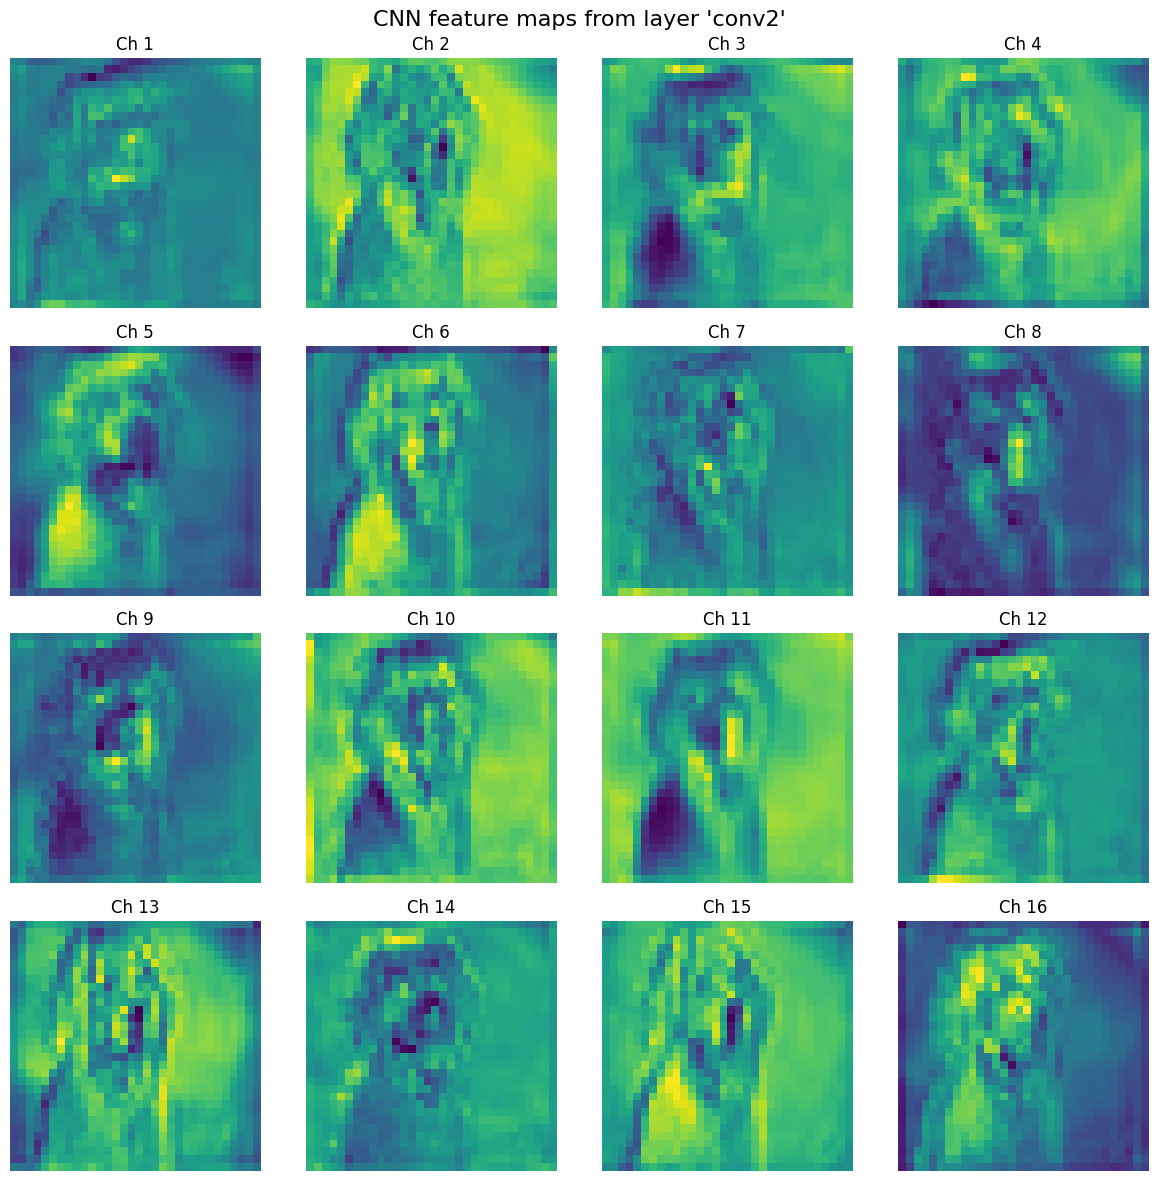

In [25]:
#@title 8. Visualize CNN feature maps
# Choose a layer to display (change layer_name to 'conv1', 'conv2', or 'conv3')
layer_name = 'conv2'   # try 'conv1', 'conv2', 'conv3'
feature_maps = cnn_activations[layer_name].squeeze(0)  # remove batch: (C, H, W)

# Plot the first 16 channels (or fewer if less than 16)
n_channels = min(16, feature_maps.shape[0])
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle(f"CNN feature maps from layer '{layer_name}'", fontsize=16)

for i in range(n_channels):
    row, col = i // 4, i % 4
    ax = axes[row, col]
    ax.imshow(feature_maps[i].cpu(), cmap='viridis')
    ax.axis('off')
    ax.set_title(f"Ch {i+1}")

# Hide unused subplots
for i in range(n_channels, 16):
    row, col = i // 4, i % 4
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

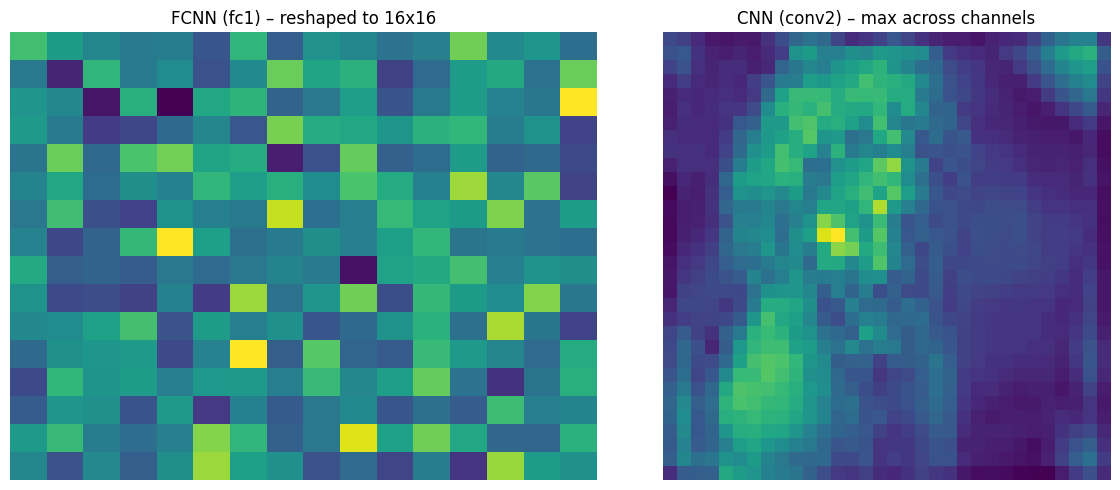

In [29]:
#@title 9. Side-by-side comparison (optional)
# Compare the first few feature maps from CNN (e.g., conv2) with the reshaped FCNN activations (fc1)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# FCNN: reshape fc1 activations as before
fcnn_act = fcnn_activations['fc1'].squeeze(0).cpu().numpy()
fcnn_2d = reshape_activations(fcnn_act, (16, 16))
axes[0].imshow(fcnn_2d, cmap='viridis', aspect='auto')
axes[0].set_title("FCNN (fc1) – reshaped to 16x16")
axes[0].axis('off')

# CNN: show a few channels combined into one image (max across channels for visualization)
cnn_feat = cnn_activations['conv2'].squeeze(0)
cnn_combined = torch.max(cnn_feat, dim=0)[0].cpu()  # max over channels
axes[1].imshow(cnn_combined, cmap='viridis')
axes[1].set_title("CNN (conv2) – max across channels")
axes[1].axis('off')

plt.tight_layout()
plt.show()